# 3 · How often do star ratings and written sentiment disagree?

**Working definition** (see notebook 2). A review is *inconsistent* when it has a polar star rating
(1–2★ or 4–5★), RoBERTa says its text has the **opposite** polarity, and at least one of the two
lexicon models agrees. 3★ reviews are excluded because a neutral rating cannot be reversed.

The answer depends heavily on how inconsistency is measured, so this notebook reports it in two
ways:

1. **Flag rates** under each automated definition, from a single model to all three
2. **An audit-adjusted estimate** of genuine reversals: flag counts multiplied by the precision that
   the manual audit measured in each stratum

There are two directions of inconsistency, and they turn out to behave differently:

* **negative text, high stars**: 4–5★ reviews whose text reads as negative
* **positive text, low stars**: 1–2★ reviews whose text reads as positive

In [1]:
import sys

sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import (BLUE, DIRECTION_COLORS, HIGH_NEG, INK_2, LOW_POS, MODEL_LABELS, MODELS, NEUTRAL,
                    SURFACE, load, rate_table, savefig, set_style, wilson)
from config import ROOT

set_style()
df = load()
polar = df[df.polar_rating].copy()
print(f"{len(polar):,} reviews with a polar rating")

638,532 reviews with a polar rating


## 1 · Flag rates under each automated definition

,reviews,rate,ci_lo,ci_hi
VADER,59178.0,0.0927,0.0920,0.0934
TextBlob,56612.0,0.0887,0.0880,0.0894
RoBERTa,19476.0,0.0305,0.0301,0.0309
Majority vote (≥2 of 3),36029.0,0.0564,0.0559,0.0570
RoBERTa + ≥1 lexicon (working definition),11429.0,0.0179,0.0176,0.0182
Unanimous (3 of 3),6748.0,0.0106,0.0103,0.0108
Working definition + RoBERTa P ≥ 0.8,4120.0,0.0065,0.0063,0.0067


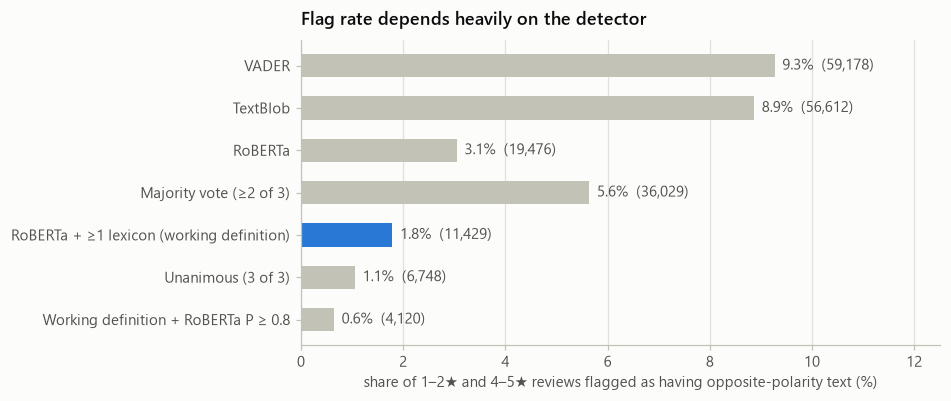

In [2]:
PRIMARY = "RoBERTa + ≥1 lexicon (working definition)"
definitions = {**{MODEL_LABELS[m]: f"rev_{m}" for m in MODELS},
               "Majority vote (≥2 of 3)": "inconsistent_majority",
               PRIMARY: "inconsistent",
               "Unanimous (3 of 3)": "inconsistent_unanimous",
               "Working definition + RoBERTa P ≥ 0.8": "inconsistent_confident"}
headline = pd.DataFrame({name: {"reviews": int(polar[c].sum()), "rate": polar[c].mean()}
                         for name, c in definitions.items()}).T
_, headline["ci_lo"], headline["ci_hi"] = wilson(headline.reviews, len(polar))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
names = list(definitions)[::-1]
colors = [BLUE if n == PRIMARY else NEUTRAL for n in names]
ax.barh(names, 100 * headline.loc[names, "rate"], height=0.55, color=colors)
for i, n in enumerate(names):
    r = headline.loc[n, "rate"]
    ax.text(100 * r + 0.15, i, f"{r:.1%}  ({int(headline.loc[n, 'reviews']):,})", va="center", color=INK_2)
ax.set_xlabel("share of 1–2★ and 4–5★ reviews flagged as having opposite-polarity text (%)")
ax.set_title("Flag rate depends heavily on the detector")
ax.grid(axis="y", visible=False)
ax.set_xlim(right=100 * headline.rate.max() * 1.35)
savefig(fig, "03_headline_rates")
headline.assign(rate=headline.rate.round(4), ci_lo=headline.ci_lo.round(4), ci_hi=headline.ci_hi.round(4))

## 2 · Audit-adjusted estimate of genuine reversals

The manual audit (notebook 2) sampled reviews at random within each **sampling stratum** below. The
estimated number of genuine reversals in a stratum is its population size times its audited
precision. The 95% interval comes from simulating each stratum's precision from its Jeffreys
posterior, Beta(k + ½, n − k + ½).

Strata where the audit found **no** genuine case, including 20 reviews that no model flagged,
contribute zero to the estimate. The audit cannot rule out a small rate there. The unflagged stratum
alone holds most reviews, so the estimate is best read as *genuine reversals among reviews that at
least one model flags*.

In [3]:
from config import ROOT

audit = pd.read_csv(ROOT / "reports" / "audit_labels.csv")
pat = polar.flag_pattern
star = pd.Series(np.where(polar.rating >= 4, "4-5 stars", "1-2 stars"), index=polar.index)
anchored = polar.inconsistent
polar["stratum"] = np.select(
    [anchored, pat == "VT-", pat == "--R", pat.isin(["V--", "-T-"]), pat == "---"],
    ["anchored, " + star, "lexicon-only (VADER+TextBlob, not RoBERTa)", "roberta-only, " + star,
     "one-lexicon-only", "unflagged"], "other")
assert (polar.stratum != "other").all()
# Audit groups that pooled both star directions are pooled here too.
audit["stratum"] = audit.group.str.replace(r"^(one-lexicon-only|unflagged), .*", r"\1", regex=True)

strata = (polar.groupby("stratum").size().to_frame("reviews")
               .join(audit.groupby("stratum").label.agg(audited="size", genuine=lambda s: (s == "I").sum())))
strata["precision"] = strata.genuine / strata.audited
strata["estimated_genuine"] = strata.reviews * strata.precision
strata = strata.sort_values("reviews", ascending=False)

rng = np.random.default_rng(0)
draws = {s: r.reviews * rng.beta(r.genuine + 0.5, r.audited - r.genuine + 0.5, 20000)
         for s, r in strata.iterrows() if r.genuine > 0}
high_star = [s for s in draws if "4-5" in s]
low_star = [s for s in draws if "1-2" in s]
n_high, n_low = (polar.rating >= 4).sum(), (polar.rating <= 2).sum()
estimate = pd.DataFrame({
    label: {"estimated genuine reversals": sum(strata.estimated_genuine[s] for s in keys),
            "95% interval": "{:,.0f}–{:,.0f}".format(*np.percentile(sum(draws[s] for s in keys), [2.5, 97.5])),
            "as % of these reviews": sum(strata.estimated_genuine[s] for s in keys) / base,
            "95% interval (%)": "{:.2%}–{:.2%}".format(*(np.percentile(sum(draws[s] for s in keys), [2.5, 97.5]) / base))}
    for label, keys, base in [("4–5★ reviews with negative text", high_star, n_high),
                              ("1–2★ reviews with positive text", low_star, n_low),
                              ("all 1–2★ and 4–5★ reviews", high_star + low_star, n_high + n_low)]}).T
display(strata.round(3))
estimate

,reviews,audited,genuine,precision,estimated_genuine
stratum,,,,,
unflagged,546043,20,0,0.000,0.000
one-lexicon-only,48413,30,0,0.000,0.000
"lexicon-only (VADER+TextBlob, not RoBERTa)",24600,30,0,0.000,0.000
"roberta-only, 4-5 stars",7619,28,7,0.250,1904.750
"anchored, 1-2 stars",6184,70,10,0.143,883.429
"anchored, 4-5 stars",5245,70,29,0.414,2172.929
"roberta-only, 1-2 stars",428,2,0,0.000,0.000


,estimated genuine reversals,95% interval,as % of these reviews,95% interval (%)
4–5★ reviews with negative text,4077.678571,"2,930–5,579",0.008237,0.59%–1.13%
1–2★ reviews with positive text,883.428571,"467–1,493",0.006157,0.33%–1.04%
all 1–2★ and 4–5★ reviews,4961.107143,"3,738–6,600",0.00777,0.59%–1.03%


## What genuine inconsistencies look like: a typology from the audit

The categories below were assigned by hand to the reviews the audit labelled genuinely inconsistent.

In [4]:
genuine = audit[audit.label == "I"].merge(polar[["review_id", "full_text"]], on="review_id")
genuine["direction"] = np.where(genuine.rating >= 4, "4–5★, negative text", "1–2★, positive text")
typology = genuine.groupby(["direction", "inconsistency_type"]).size().rename("reviews").reset_index()
typology["share_within_direction"] = typology.reviews / typology.groupby("direction").reviews.transform("sum")
examples = genuine.groupby("inconsistency_type").full_text.first().str.slice(0, 140)
display(typology.round(2))
examples.to_frame("example")

,direction,inconsistency_type,reviews,share_within_direction
0,"1–2★, positive text",placeholder_rating,1,0.10
1,"1–2★, positive text",praise_low_stars,8,0.80
2,"1–2★, positive text",price,1,0.10
3,"4–5★, negative text",fulfilment_or_seller,7,0.19
4,"4–5★, negative text",price,1,0.03
5,"4–5★, negative text",product_problem,27,0.75
6,"4–5★, negative text",update_after_failure,1,0.03


,example
inconsistency_type,
fulfilment_or_seller,Did nothing. I expected instant results at lea...
placeholder_rating,Smells great though. Hopefully I remember to e...
praise_low_stars,Great gift for my teenage daughter. Great gift...
price,HIGH COST of Razor Blades. VERY EXPENSIVE!
product_problem,Not a fan of the clasp . Dose not fit the neck...
update_after_failure,It came on time. It takes some time. But it wi...


## Flag rate by star rating

These are the working-definition flag rates for each star rating, with 95% CIs. The composition
table shows which direction the flagged reviews come from. Remember that audited precision differs
by direction: higher for 4–5★ flags than for 1–2★ flags.

,rating,direction,k,n,rate,lo,hi,unanimous_rate
0,1.0,"positive text, low stars",2478,100888,0.0246,0.0236,0.0255,0.0194
1,2.0,"positive text, low stars",3706,42601,0.0870,0.0844,0.0897,0.0721
2,4.0,"negative text, high stars",2881,78608,0.0367,0.0354,0.0380,0.0112
3,5.0,"negative text, high stars",2364,416435,0.0057,0.0055,0.0059,0.0020


,inconsistent reviews,share
direction,,
"positive text, low stars",6184,0.541
"negative text, high stars",5245,0.459


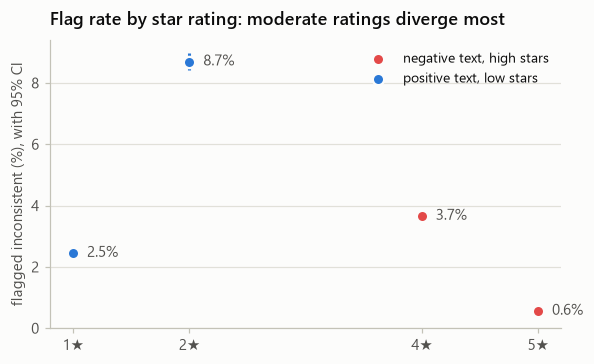

In [5]:
by_star = rate_table(polar, "rating")
by_star["direction"] = np.where(by_star.rating >= 4, HIGH_NEG, LOW_POS)
by_star_unan = rate_table(polar, "rating", "inconsistent_unanimous")
by_star["unanimous_rate"] = by_star_unan.rate.to_numpy()

fig, ax = plt.subplots(figsize=(6, 3.4))
for direction, g in by_star.groupby("direction"):
    ax.vlines(g.rating, 100 * g.lo, 100 * g.hi, color=DIRECTION_COLORS[direction], linewidth=2)
    ax.scatter(g.rating, 100 * g.rate, color=DIRECTION_COLORS[direction], s=55, zorder=3,
               edgecolor=SURFACE, linewidth=1.5, label=direction)
    for _, r in g.iterrows():
        ax.text(r.rating + 0.12, 100 * r.rate, f"{r.rate:.1%}", va="center", color=INK_2)
ax.set_xticks([1, 2, 4, 5], ["1★", "2★", "4★", "5★"])
ax.set_ylim(bottom=0)
ax.set_ylabel("flagged inconsistent (%), with 95% CI")
ax.set_title("Flag rate by star rating: moderate ratings diverge most")
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
savefig(fig, "03_rate_by_star")
display(by_star[["rating", "direction", "k", "n", "rate", "lo", "hi", "unanimous_rate"]].round(4))

composition = polar[polar.inconsistent].direction.value_counts()
composition.to_frame("inconsistent reviews").assign(share=(composition / composition.sum()).round(3))

## Over time

Only years with at least 1,000 polar reviews are shown.

dir_group,"negative text, high stars","positive text, low stars"
year,,
2007,0.0078,0.1184
2008,0.0134,0.0659
2009,0.0173,0.0947
2010,0.0092,0.0843
2011,0.0145,0.0409
2012,0.0116,0.0531
2013,0.0110,0.0449
2014,0.0096,0.0701
2015,0.0084,0.0588


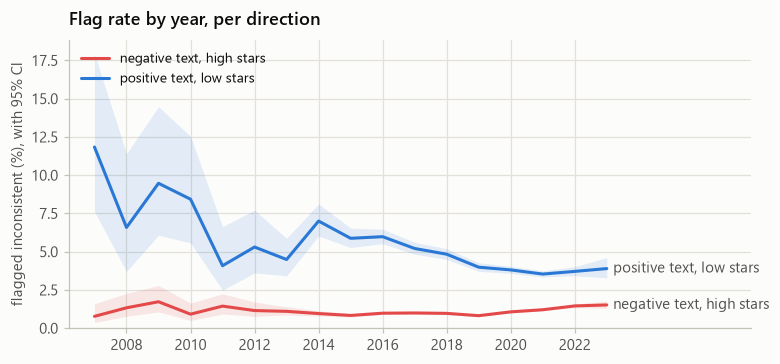

In [6]:
years = rate_table(polar.assign(dir_group=np.where(polar.rating >= 4, HIGH_NEG, LOW_POS)),
                   ["dir_group", "year"])
years = years[years.groupby("year").n.transform("sum") >= 1000]

fig, ax = plt.subplots(figsize=(8, 3.4))
for direction, g in years.groupby("dir_group"):
    c = DIRECTION_COLORS[direction]
    ax.fill_between(g.year, 100 * g.lo, 100 * g.hi, color=c, alpha=0.12, linewidth=0)
    ax.plot(g.year, 100 * g.rate, color=c, label=direction)
    last = g.iloc[-1]
    ax.text(last.year + 0.2, 100 * last.rate, direction, color=INK_2, va="center")
ax.set_ylim(bottom=0)
ax.set_xlim(right=years.year.max() + 4.5)
ax.set_xticks(range(int(years.year.min()) + 1, int(years.year.max()) + 1, 2))
ax.set_ylabel("flagged inconsistent (%), with 95% CI")
ax.set_title("Flag rate by year, per direction")
ax.legend(loc="upper left")
savefig(fig, "03_rate_by_year")
years.pivot(index="year", columns="dir_group", values="rate").round(4)

## A continuous view: stars minus the rating the text implies

The *implied rating* is the average star rating given to reviews with the same sentiment score. It
comes from an isotonic fit on the ensemble score. **Discrepancy = stars − implied rating.** Positive
values mean the stars are more generous than the text, and negative values mean they are harsher.

,value
|discrepancy| ≥ 1 star,0.155
|discrepancy| ≥ 2 stars,0.050
stars ≥ 2 above text (generous),0.017
stars ≥ 2 below text (harsh),0.033
"mean |discrepancy|, consistent reviews",0.510
"mean |discrepancy|, inconsistent reviews",2.622


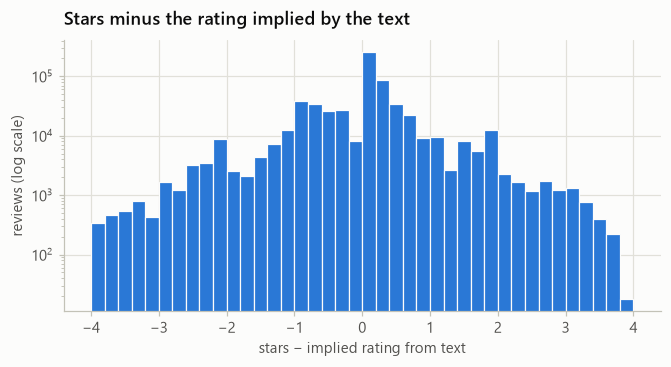

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
edges = np.linspace(-4, 4, 41)
ax.hist(polar.discrepancy, bins=edges, color=BLUE, edgecolor=SURFACE, linewidth=0.8)
ax.set_yscale("log")
ax.set_xlabel("stars − implied rating from text")
ax.set_ylabel("reviews (log scale)")
ax.set_title("Stars minus the rating implied by the text")
savefig(fig, "03_discrepancy_hist")
pd.Series({
    "|discrepancy| ≥ 1 star": (polar.discrepancy.abs() >= 1).mean(),
    "|discrepancy| ≥ 2 stars": (polar.discrepancy.abs() >= 2).mean(),
    "stars ≥ 2 above text (generous)": (polar.discrepancy >= 2).mean(),
    "stars ≥ 2 below text (harsh)": (polar.discrepancy <= -2).mean(),
    "mean |discrepancy|, consistent reviews": polar.loc[~polar.inconsistent, "discrepancy"].abs().mean(),
    "mean |discrepancy|, inconsistent reviews": polar.loc[polar.inconsistent, "discrepancy"].abs().mean(),
}).round(3).to_frame("value")

## What inconsistent reviews look like

These are random examples where all three models agree the text contradicts the stars.

In [8]:
def show(frame, n=6, seed=1):
    for _, r in frame.sample(n, random_state=seed).iterrows():
        text = r.full_text if len(r.full_text) < 320 else r.full_text[:320] + "…"
        print(f"{int(r.rating)}★ | VADER {r.vader:+.2f} TextBlob {r.textblob:+.2f} RoBERTa {r.roberta:+.2f}")
        print(f"   {text}\n")


print("=== negative text, high stars ===\n")
show(polar[polar.inconsistent_unanimous & (polar.rating >= 4)])
print("=== positive text, low stars ===\n")
show(polar[polar.inconsistent_unanimous & (polar.rating <= 2)])

=== negative text, high stars ===

4★ | VADER -0.17 TextBlob -0.29 RoBERTa -0.90
   Disappointed. when the package came and i opened it , the box that my hair remover looked that it had been smashed and then when i opened the box , the battery was missing... i'm glad i had AA batteries, i still can't believe how bad the box was and also didn't come with a battery which it said battery included and the…

5★ | VADER -0.38 TextBlob -0.27 RoBERTa -0.77
   Has a new name that is awful I prefer the ... Has a new name that is awful I prefer the original which is what you see on the bottle now. It seems to work as well.

4★ | VADER -0.46 TextBlob -0.66 RoBERTa -0.94
   Disappointing !! Doesn't hold well, lashes fall off in a few hours. Save your money !!!

5★ | VADER -0.57 TextBlob -1.00 RoBERTa -0.66
   Ergonomic. I have arthritis & always have a terrible time using a fingernail clipper. Problem solved.

4★ | VADER -0.53 TextBlob -0.17 RoBERTa -0.93
   Light Medium no-longer available. I'm ve

## A sample for manual validation

The audit above was done by the AI assistant that built the pipeline. For an independent check, the
file below holds a fresh random, shuffled sample: 100 reviews per direction flagged by the working
definition, plus 100 unflagged controls. The `human_label` and `reason` columns are empty for human
annotators, using the same **I / M / C / U** scheme as notebook 2. Comparing their labels with
`reports/audit_labels.csv` measures agreement between annotators.

In [9]:
sample = pd.concat([
    polar[polar.inconsistent & (polar.rating >= 4)].sample(100, random_state=0),
    polar[polar.inconsistent & (polar.rating <= 2)].sample(100, random_state=0),
    polar[~polar.inconsistent].sample(100, random_state=0),
]).sample(frac=1, random_state=0)
out = sample[["review_id", "rating", "title", "text", "vader", "textblob", "roberta", "n_models_reversed"]]
out = out.assign(flagged=sample.inconsistent, human_label="", reason="")
path = ROOT / "reports" / "validation_sample.csv"
out.to_csv(path, index=False, encoding="utf-8-sig")
print(f"wrote {path.relative_to(ROOT).as_posix()} ({len(out)} reviews)")

wrote reports/validation_sample.csv (300 reviews)


## For context: 3★ reviews

3★ reviews are excluded from the inconsistency definition. The table shows how their text is
classified.

In [10]:
three = df[df.rating == 3]
pd.DataFrame({MODEL_LABELS[m]: three[f"{m}_pol"].map({-1: "negative", 0: "neutral", 1: "positive"})
              .value_counts(normalize=True) for m in MODELS}).round(3)

,VADER,TextBlob,RoBERTa
negative,0.243,0.159,0.482
neutral,0.119,0.186,0.209
positive,0.638,0.655,0.309
